# Text Annotations


This section showcases text annotations. It contains examples of how to attach explanatory text to charts — naming a series, explaining an outlier, calling out a point — with the `texts` parameter that every chart function accepts, and how to add texts to an already rendered figure with the [datachart.utils.Annotate](../../../references/utils/#datachart.utils.Annotate) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-texts), which maps common tasks to the attribute or style key that does the job.


## Text Input Attributes

Every chart function takes a `texts` parameter: a single text annotation or a list of them. Each annotation is a dictionary:

```python
{
    "text": str,                    # The annotation text (required)
    "x": Union[int, float],         # The x-axis position of the text
    "y": Union[int, float],         # The y-axis position of the text
    "coords": Optional[str],        # The coordinate system of the position: "data" (default) or "axes"
    "target": Optional[tuple],      # The (x, y) data point the connector points to; no target, no connector
    "style": Optional[dict],        # Per-text style overrides (the plot_text_* style attributes)
}
```

With multiple charts drawn as subplots, a list of lists assigns the annotations per chart, exactly as `vlines` and `hlines` do. For the full definitions, see the [datachart.typings.TextAttrs](../../../references/typings/#datachart.typings.TextAttrs) and [datachart.typings.TextStyleAttrs](../../../references/typings/#datachart.typings.TextStyleAttrs) typings.


In [1]:
from datachart.charts import BarChart, LineChart
from datachart.utils import Annotate, Panel
from datachart.constants import ARROW_STYLE, FIG_SIZE


## Basics

The examples in this guide share one dataset: the monthly climate normals of Ljubljana's weather station — the mean temperature (in °C) and the total precipitation (in mm) of each month, rounded from the published values. The data lives in a hidden cell.


In [2]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# mean monthly temperature in °C
TEMPERATURE = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
# total monthly precipitation in mm
PRECIPITATION = [69, 70, 88, 99, 109, 144, 115, 137, 147, 147, 130, 107]

temperature_data = [{"x": i, "y": value} for i, value in enumerate(TEMPERATURE)]
precipitation_data = [
    {"label": month, "y": value} for month, value in zip(MONTHS, PRECIPITATION)
]


A text annotation is declared with the chart. By default its position is in data coordinates, and giving it a `target` draws a connector from the text to that data point:


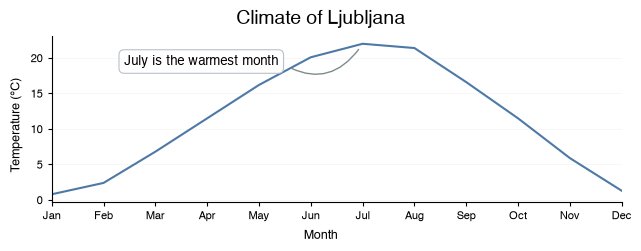

In [3]:
LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    texts={
        "text": "July is the warmest month",
        "x": 1.4,
        "y": 19.5,
        "target": (6, 22.0),
    },
).show()


Because the annotation is part of the chart declaration — not an afterthought drawn onto the figure — it follows the active theme and survives figure composition: composing the figure with [Panel](../panel/) or [Grid](../grid/) redraws the annotation with the chart.


## Customizing the Texts

Every customization is either an attribute of the annotation dictionary or a `plot_text_*` style key in its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                    | Use                                                        | See |
| :-------------------------------------------- | :--------------------------------------------------------- | :-- |
| place a note at a data point                  | `x`, `y` (data coordinates by default)                     | [Placement and coordinates](#placement-and-coordinates) |
| pin a note to the figure, whatever the limits | `"coords": "axes"`                                     | [Placement and coordinates](#placement-and-coordinates) |
| point at a data point                         | `target`                                                   | [Placement and coordinates](#placement-and-coordinates) |
| change the connector look                     | `"style": {"plot_text_arrow_style": ...}`              | [Connector looks](#connector-looks) |
| restyle the text or its box                   | the `plot_text_*` keys in `style`                          | [Text and box style](#text-and-box-style) |
| hide the background box                       | `"style": {"plot_text_box_visible": False}`            | [Text and box style](#text-and-box-style) |
| annotate an already rendered figure           | `Annotate(figure, texts)`                                  | [Annotating finished figures](#annotating-finished-figures) |
| change the defaults for every chart           | the `plot_text_*` configuration keys                       | [Text configuration](#text-configuration) |


### Placement and Coordinates

The text position is interpreted in data coordinates by default, so the note moves with the data. With `"coords": "axes"` the position becomes a fraction of the axes — `(0, 0)` the bottom-left corner, `(1, 1)` the top-right — which keeps the note in place whatever the axis limits are. The `target` is **always** in data coordinates: an axes-placed note still points at its data point. One annotation carries one target; several connectors mean several annotations.


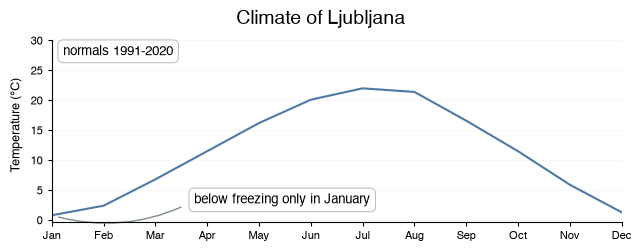

In [4]:
LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    ymax=30,
    texts=[
        # pinned to the axes: stays in the corner whatever the limits
        {"text": "normals 1991-2020", "x": 0.02, "y": 0.94, "coords": "axes"},
        # placed on the axes, pointing at a data point
        {
            "text": "below freezing only in January",
            "x": 0.25,
            "y": 0.12,
            "coords": "axes",
            "target": (0, 0.8),
        },
    ],
).show()


### Connector Looks

The connector's look is set by the `plot_text_arrow_style` style key, whose values are named by the [datachart.constants.ARROW_STYLE](../../../references/constants/#datachart.constants.ARROW_STYLE) constant. Each value is a complete look — the line shape, its curvature, and the gap on the text side. The default is the curved plain line, `ARROW_STYLE.CURVE`:


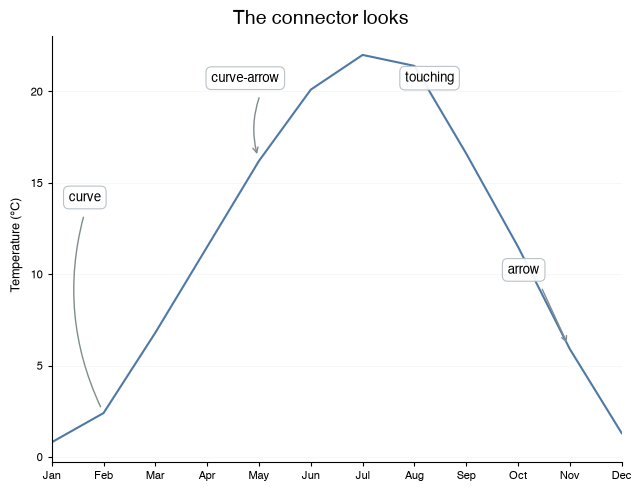

In [5]:
looks = [
    (ARROW_STYLE.CURVE, 0.03, 0.62),
    (ARROW_STYLE.CURVE_ARROW, 0.28, 0.9),
    (ARROW_STYLE.TOUCHING, 0.62, 0.9),
    (ARROW_STYLE.ARROW, 0.8, 0.45),
]

LineChart(
    data=temperature_data,
    title="The connector looks",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    texts=[
        {
            "text": look,
            "x": x,
            "y": y,
            "coords": "axes",
            "target": (index * 3 + 1, TEMPERATURE[index * 3 + 1]),
            "style": {"plot_text_arrow_style": look},
        }
        for index, (look, x, y) in enumerate(looks)
    ],
).show()


The connector also places itself: it leaves the box from the side facing the target, a curved look bows toward the side with the most open space — away from the chart's data — and a connector shorter than its own gaps straightens, then disappears entirely.

A look is a starting point, not a straitjacket: the individual `plot_text_arrow_*` keys override single properties of it — `plot_text_arrow_curve` pins the bow (side and depth) exactly, and `plot_text_arrow_color` and `plot_text_arrow_width` restyle the stroke. A raw matplotlib arrow style string (such as `"-|>"`) is also accepted.


### Text and Box Style

The text and its background box are styled by the `plot_text_*` keys of the annotation's `style` dictionary — the same keys that live in every theme, so a per-text override changes exactly one annotation. The box can be hidden entirely for a quieter, label-like note:


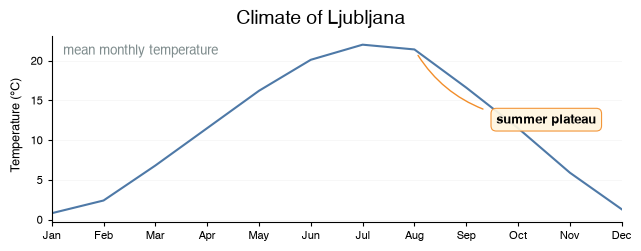

In [6]:
LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    texts=[
        # a quiet, boxless comment
        {
            "text": "mean monthly temperature",
            "x": 0.02,
            "y": 0.92,
            "coords": "axes",
            "style": {"plot_text_box_visible": False, "plot_text_color": "#7F8C8D"},
        },
        # a loud one, restyled box and text
        {
            "text": "summer plateau",
            "x": 0.78,
            "y": 0.55,
            "coords": "axes",
            "target": (7, 21.4),
            "style": {
                "plot_text_weight": "bold",
                "plot_text_box_facecolor": "#FFF6E0",
                "plot_text_box_edgecolor": "#F28E2B",
                "plot_text_arrow_color": "#F28E2B",
            },
        },
    ],
).show()


## Annotating Finished Figures

A figure that is already rendered — by a chart function or by [Panel](../panel/) — is annotated post hoc with the [datachart.utils.Annotate](../../../references/utils/#datachart.utils.Annotate) function. It returns a **new** figure with the texts added, leaving the source figure untouched; the annotations become part of the new figure's chart declaration, so they compose onward like any other. Grid figures and multi-subplot figures are rejected: annotate the sources before composing them.


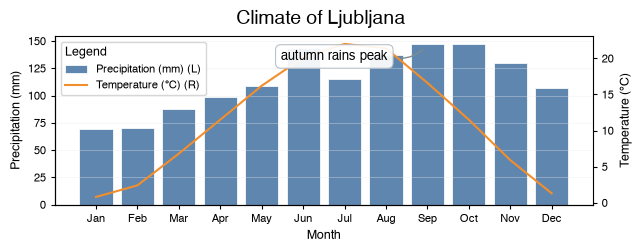

In [7]:
precipitation = BarChart(data=precipitation_data, subtitle="Precipitation (mm)")
temperature = LineChart(data=temperature_data, subtitle="Temperature (°C)")

climograph = Panel(
    [precipitation, temperature],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_legend=True,
)

Annotate(
    climograph,
    texts={
        "text": "autumn rains peak",
        "x": 0.42,
        "y": 0.88,
        "coords": "axes",
        "target": (8, 147),
    },
).show()


## Text Configuration

The defaults every annotation falls back on — the font, the box face and edge, the connector look and color — are part of the global configuration, under the keys that start with `plot_text_`. Every predefined theme sets them to match its own look, and they are changed like any other setting, through [datachart.config.config.update_config](../../../references/config/#datachart.config.Config.update_config); see the [Config](../../styling/config/) guide for the configuration system as a whole. The current keys and their values in the active theme are:


In [8]:
from datachart.config import config

{key: value for key, value in config.config.items() if key.startswith("plot_text_")}


{'plot_text_color': None,
 'plot_text_size': 9.5,
 'plot_text_weight': 'normal',
 'plot_text_halign': 'left',
 'plot_text_valign': 'center',
 'plot_text_alpha': 1.0,
 'plot_text_box_visible': True,
 'plot_text_box_style': 'round,pad=0.4',
 'plot_text_box_facecolor': '#FFFFFF',
 'plot_text_box_edgecolor': '#B4BCC4',
 'plot_text_box_edge_width': 0.8,
 'plot_text_box_alpha': 0.92,
 'plot_text_arrow_style': 'curve',
 'plot_text_arrow_curve': None,
 'plot_text_arrow_color': '#7F8C8D',
 'plot_text_arrow_width': 1.0}

A `plot_text_*` key in an annotation's `style` dictionary always wins over the configuration. The configuration is the place for a default that should hold for every annotation of a document.
